# Bath dataset variation and synthetic-label signal

**Purpose.** This notebook provides a reproducible, data-grounded justification for the claim that the observed Bath export contains environmental variation, but limited variation across the thermal-comfort decision regions required by the synthetic-label active-learning experiment.

It tests five claims using the repository's real adapters and configured dataset paths:

1. Bath temperature varies, but less than LaSDPC temperature.
2. Bath humidity varies substantially, so the dataset is not simply 'uniform'.
3. The outdoor-temperature-driven clothing assumption compresses the PMV signal.
4. The remaining Bath PMV signal is small relative to the configured synthetic-label noise.
5. No physically supported `too_warm` PMV region occurs during the monitored period.

> Scope: these findings describe the monitored period and the current modelling assumptions. They do **not** claim that Connaught Mansions is never warm, or that real occupants were comfortable. The dataset contains no occupant votes. Building-level results are confidential project material.

### Code explanation: prepare the analysis environment

**Purpose.** Load the numerical, plotting and project modules used throughout the notebook, then confirm that both configured datasets are available.

**What the code does.**

1. Imports pandas, NumPy, Matplotlib and the normal distribution used in later calculations.
2. Imports the repository's Bath adapter, schema, PMV, clothing, synthetic-label and validation functions so the notebook uses production logic rather than duplicate formulas.
3. Sets readable table and plot defaults.
4. Resolves the Bath directory and LaSDPC CSV from project configuration and stops immediately if either path is missing.

**Why this code is included.** A justification notebook is only credible if it uses the same paths and implementation as the actual experiment.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

from dissertation_code import config, pipeline
from dissertation_code.comfort import clothing
from dissertation_code.comfort import pmv as pmv_model
from dissertation_code.comfort import synthetic_labels as sl
from dissertation_code.data import bath, schema, sources
from dissertation_code.evaluation import validation

pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-whitegrid')

print('Bath directory:', config.BATH_DATASET_DIR)
print('LaSDPC file:  ', config.LASDPC_DATASET_PATH)
assert config.BATH_DATASET_DIR.exists(), config.BATH_DATASET_DIR
assert config.LASDPC_DATASET_PATH.exists(), config.LASDPC_DATASET_PATH

Bath directory: /home/sai/Desktop/projects/srinidhi_project/DigitalTwinData
LaSDPC file:   /home/sai/Desktop/projects/srinidhi_project/datasets/iot-dataset/Dataset_slice.csv


#### Output explanation

**What the output is.** Two absolute local paths are printed: the configured Bath data directory and the configured LaSDPC CSV. No exception follows the paths.

**What the output means.** Both required data sources were found, so the remaining cells can use the real project data. The assertions also prevent a misleading notebook run against missing or incorrectly configured inputs.

**Important interpretation boundary.** This output verifies file availability only. It says nothing yet about data quality, label quality or active-learning performance.

## 1. Load the real datasets

Bath temperature and RH are natively paired in the workbooks, so the Bath adapter does not resample them. The two external loggers are retained only to derive and verify the local-weather clothing context; they are excluded from the comfort-model observations. LaSDPC uses the project's existing 10-minute pairing pipeline.

### Code explanation: load, separate and label the real datasets

**Purpose.** Build the exact Bath and LaSDPC analysis frames and summarise their spatial and temporal coverage.

**What the code does.**

1. Loads every valid Bath sensor sheet, including external sensors, through the alias-aware Bath adapter.
2. Splits indoor rooms from the two external sensors using the canonical zone names.
3. Attaches outdoor-driven clothing insulation to indoor Bath observations.
4. Generates the Bath synthetic labels with the warm tail merged for this observed period, while the LaSDPC pipeline retains its three-class target.
5. Reports row counts, zone counts and date ranges for the three frames.

**Why this code is included.** The later variation and PMV comparisons need clearly defined populations rather than mixing indoor and outdoor measurements.

In [2]:
everything = sources.load_bath_wide(
    data_dir=config.BATH_DATASET_DIR, include_external=True
)
is_external = everything[schema.ZONE].isin(bath.EXTERNAL_SENSORS)
bath_indoor = everything.loc[~is_external].reset_index(drop=True)
bath_external = everything.loc[is_external].reset_index(drop=True)

bath_with_clo = clothing.attach_clo(bath_indoor, bath_external)
bath_labelled = sl.generate_labels(
    bath_with_clo,
    sl.GeneratorConfig(
        clo_column=clothing.CLOTHING_INSULATION,
        merge_warm=True,
    ),
)
lasdpc_labelled = pipeline.build_labelled_dataset(source='lasdpc')

coverage = pd.DataFrame(
    {
        'Bath indoor': {
            'rows': len(bath_indoor),
            'zones': bath_indoor[schema.ZONE].nunique(),
            'start': bath_indoor[schema.TIMESTAMP].min(),
            'end': bath_indoor[schema.TIMESTAMP].max(),
        },
        'Bath external': {
            'rows': len(bath_external),
            'zones': bath_external[schema.ZONE].nunique(),
            'start': bath_external[schema.TIMESTAMP].min(),
            'end': bath_external[schema.TIMESTAMP].max(),
        },
        'LaSDPC paired': {
            'rows': len(lasdpc_labelled),
            'zones': lasdpc_labelled[schema.ZONE].nunique(),
            'start': lasdpc_labelled[schema.TIMESTAMP].min(),
            'end': lasdpc_labelled[schema.TIMESTAMP].max(),
        },
    }
).T
coverage

,rows,zones,start,end
Bath indoor,419602,7,2023-11-14 11:40:00,2024-07-10 15:55:00
Bath external,94428,2,2023-11-14 11:20:00,2024-07-10 17:10:00
LaSDPC paired,1355,4,2026-01-16 19:40:00-03:00,2026-01-19 07:20:00-03:00


#### Output explanation

**What the output is.** A coverage table shows 419,602 Bath indoor rows across 7 rooms, 94,428 Bath external rows across 2 sensors, and 1,355 paired LaSDPC rows across 4 zones, together with their observed date ranges.

**What the output means.** Both datasets satisfy the multi-zone T+RH requirement. Bath is much larger and spans roughly eight analysed months, whereas the current LaSDPC slice covers only about two and a half days. The explicit external split also confirms that outdoor readings are used as context rather than mixed into the indoor model pool.

**Important interpretation boundary.** Different row counts and monitoring durations do not by themselves make one dataset more learnable; the label signal and evaluation design must be examined separately.

## 2. Was local Bath weather considered?

Yes. The adopted clothing assumption is driven by the two external loggers in the building export, not by a generic calendar. This cell also parses the separate local weather-station file and compares daily temperatures where the two sources overlap.

The weather-station export is headerless, contains encoding artefacts and only covers January and June. Therefore it is an independent cross-check rather than the primary driver.

### Code explanation: compare the building's external sensors with local weather

**Purpose.** Test whether local Bath weather was genuinely considered when selecting the contextual clothing calibration.

**What the code does.**

1. Reads the weather-station CSV using its original encoding and extracts numeric temperature values from the source text.
2. Combines the date and 12-hour time columns into timestamps.
3. Aggregates both the weather station and the building's external loggers to daily mean temperature.
4. Keeps only dates available in both sources, then calculates Pearson correlation and mean absolute difference.
5. Displays source coverage and the two comparison statistics.

**Why this code is included.** This directly addresses whether the Bath-specific local environment was ignored or replaced by a generic seasonal assumption.

In [3]:
weather_path = config.BATH_DATASET_DIR / 'weather_station.csv'
weather_raw = pd.read_csv(
    weather_path, header=None, encoding='latin1', skip_blank_lines=True
)
weather_temperature = (
    weather_raw[2]
    .astype(str)
    .str.extract(r'([-+]?\d+(?:\.\d+)?)', expand=False)
    .astype(float)
)
weather_timestamp = pd.to_datetime(
    weather_raw[0].astype(str) + ' ' + weather_raw[1].astype(str),
    format='%d/%m/%Y %I:%M %p',
)
weather = pd.DataFrame(
    {'timestamp': weather_timestamp, 'weather_station_temperature': weather_temperature}
)

external_daily = (
    bath_external.assign(date=bath_external[schema.TIMESTAMP].dt.floor('D'))
    .groupby('date')[schema.TEMPERATURE]
    .mean()
    .rename('building_external_temperature')
)
station_daily = (
    weather.assign(date=weather['timestamp'].dt.floor('D'))
    .groupby('date')['weather_station_temperature']
    .mean()
)
weather_overlap = pd.concat([external_daily, station_daily], axis=1, sort=True).dropna()
weather_correlation = weather_overlap.corr().iloc[0, 1]
weather_mae = (
    weather_overlap['building_external_temperature']
    - weather_overlap['weather_station_temperature']
).abs().mean()

weather_evidence = pd.Series(
    {
        'weather-station rows': len(weather),
        'weather-station start': weather['timestamp'].min(),
        'weather-station end': weather['timestamp'].max(),
        'station months present': sorted(weather['timestamp'].dt.month.unique().tolist()),
        'overlapping daily means': len(weather_overlap),
        'daily-temperature correlation': weather_correlation,
        'daily mean absolute difference (degC)': weather_mae,
    },
    name='local-weather evidence',
)
weather_evidence

weather-station rows                                   17529
weather-station start                    2024-01-01 00:04:00
weather-station end                      2024-06-30 23:59:00
station months present                                [1, 6]
overlapping daily means                                   46
daily-temperature correlation                          0.985
daily mean absolute difference (degC)                 1.7108
Name: local-weather evidence, dtype: object

#### Output explanation

**What the output is.** The series reports 17,529 station readings, data present in January and June, 46 overlapping daily means, correlation 0.9850 and mean absolute difference 1.7108 degrees C.

**What the output means.** The very high correlation shows that the building's external loggers and separate weather station follow the same local daily pattern. The building loggers provide the more continuous, time-aligned context required by the clothing rule, while the station acts as an independent reasonableness check.

**Important interpretation boundary.** Correlation does not mean the sensors are interchangeable or prove that the clothing equation is correct. Exposure, siting and calibration can explain the remaining absolute difference.

### Code explanation: plot the two outdoor-temperature series

**Purpose.** Provide a visual check of agreement, offsets and missing periods that cannot be seen from one correlation coefficient.

**What the code does.**

1. Creates an eleven-by-four-inch Matplotlib figure.
2. Plots daily means from the building external loggers and the local station on the same date axis.
3. Adds units, a title and a legend, then renders the figure.

**Why this code is included.** Visual comparison reveals whether a strong summary statistic is driven by only a small or unusual overlap.

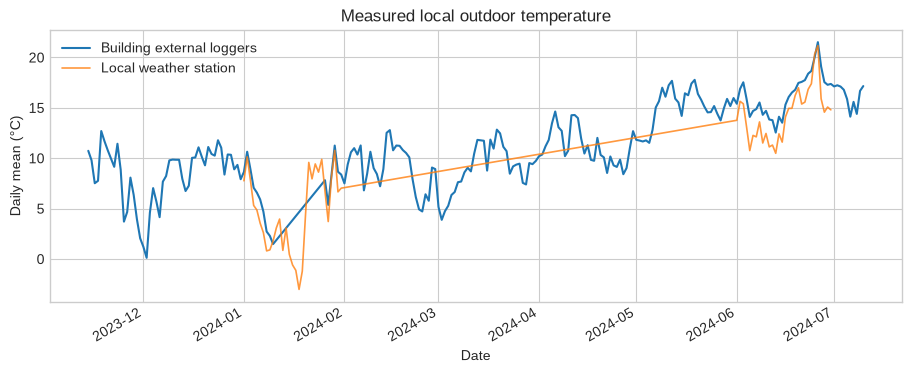

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
external_daily.plot(ax=ax, label='Building external loggers', linewidth=1.5)
station_daily.plot(ax=ax, label='Local weather station', linewidth=1.2, alpha=0.8)
ax.set(title='Measured local outdoor temperature', xlabel='Date', ylabel='Daily mean (°C)')
ax.legend()
plt.show()

#### Output explanation

**What the output is.** A two-line time-series figure compares the daily mean outdoor temperatures measured by the building loggers and the local weather station.

**What the output means.** Where both sources exist, their rises and falls track closely, supporting the numerical correlation. The plot also makes the station's limited temporal coverage visible and explains why the building loggers were used for continuous contextual calibration.

**Important interpretation boundary.** Outdoor temperature remains an input to the synthetic comfort assumption only; this figure does not add it to the active-learning feature set.

**Interpretation.** A strong daily correlation shows that the building's external sensors track the separate local weather source. A fixed offset or non-zero absolute difference is plausible because the sensors have different exposure and siting. This supports using the building loggers for time-aligned local context; it does not make outdoor weather a model feature.

## 3. Environmental variation

Standard deviation and interquartile range describe where most observations lie; minimum and maximum alone can be dominated by rare readings.

### Code explanation: quantify environmental variation

**Purpose.** Measure how much temperature and RH vary in Bath and LaSDPC before attributing the active-learning result to either dataset.

**What the code does.**

1. Defines one reusable summary function for temperature and RH.
2. Calculates minima, maxima, standard deviations and interquartile ranges for each dataset.
3. Calculates the share of observations above the 75% RH threshold.
4. Combines the Bath and LaSDPC results into one comparison table.

**Why this code is included.** The claim that Bath has too little variation must be tested numerically rather than inferred from its average temperature.

In [5]:
def variation_row(frame, dataset):
    temperature = frame[schema.TEMPERATURE]
    humidity = frame[schema.RELATIVE_HUMIDITY]
    return {
        'dataset': dataset,
        'temperature min': temperature.min(),
        'temperature max': temperature.max(),
        'temperature std': temperature.std(),
        'temperature IQR': temperature.quantile(0.75) - temperature.quantile(0.25),
        'RH min': humidity.min(),
        'RH max': humidity.max(),
        'RH std': humidity.std(),
        'RH IQR': humidity.quantile(0.75) - humidity.quantile(0.25),
        'RH > 75%': (humidity > 75).mean(),
    }

environmental_variation = pd.DataFrame(
    [
        variation_row(bath_indoor, 'Bath indoor'),
        variation_row(lasdpc_labelled, 'LaSDPC paired'),
    ]
).set_index('dataset')
environmental_variation

,temperature min,temperature max,temperature std,temperature IQR,RH min,RH max,RH std,RH IQR,RH > 75%
dataset,,,,,,,,,
Bath indoor,10.3930,22.9270,1.9734,3.0590,48.9000,94.300,5.5161,6.6000,0.2012
LaSDPC paired,15.1421,27.5476,3.3786,3.5562,51.2533,86.604,8.7192,16.0603,0.2945


#### Output explanation

**What the output is.** The table reports Bath temperature standard deviation 1.9734 degrees C and RH standard deviation 5.5161 percentage points, compared with LaSDPC values of 3.3786 and 8.7192. Bath also has 20.12% of readings above 75% RH.

**What the output means.** Bath is not constant: it has material temperature and humidity variation and frequent high-RH observations. It is, however, narrower than LaSDPC, especially in temperature spread. This supports describing the issue as reduced variation, not absence of variation.

**Important interpretation boundary.** Environmental spread is only one part of learnability. The next cells examine how the PMV/clothing transformation and synthetic noise change that raw sensor variation.

### Code explanation: visualise the temperature and RH distributions

**Purpose.** Show the shape and overlap of both datasets rather than relying only on minimum, maximum and standard deviation.

**What the code does.**

1. Creates side-by-side density histograms for temperature and RH.
2. Uses normalised density so datasets with very different row counts can be compared fairly by shape.
3. Marks the 75% RH threshold on the humidity panel.

**Why this code is included.** Distribution shape determines how many observations occur near a learnable boundary; equal-looking standard deviations can still hide very different shapes.

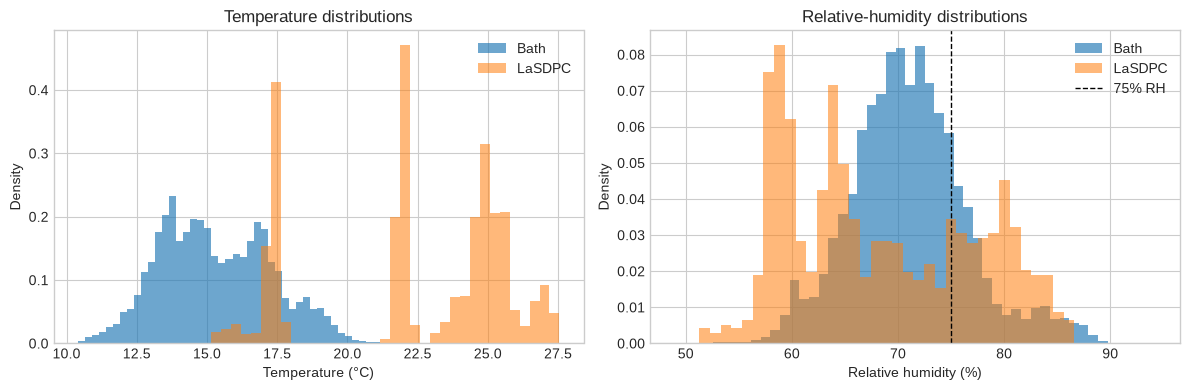

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bath_indoor[schema.TEMPERATURE], bins=50, density=True, alpha=0.65, label='Bath')
axes[0].hist(lasdpc_labelled[schema.TEMPERATURE], bins=35, density=True, alpha=0.55, label='LaSDPC')
axes[0].set(title='Temperature distributions', xlabel='Temperature (°C)', ylabel='Density')
axes[0].legend()

axes[1].hist(bath_indoor[schema.RELATIVE_HUMIDITY], bins=50, density=True, alpha=0.65, label='Bath')
axes[1].hist(lasdpc_labelled[schema.RELATIVE_HUMIDITY], bins=35, density=True, alpha=0.55, label='LaSDPC')
axes[1].axvline(75, color='black', linestyle='--', linewidth=1, label='75% RH')
axes[1].set(title='Relative-humidity distributions', xlabel='Relative humidity (%)', ylabel='Density')
axes[1].legend()
plt.tight_layout()
plt.show()

#### Output explanation

**What the output is.** A two-panel figure displays the Bath and LaSDPC temperature distributions on the left and RH distributions on the right, with the 75% RH line marked.

**What the output means.** Bath observations are more concentrated in a cooler, narrower temperature range, while LaSDPC spans a broader thermal range. Both datasets contain meaningful RH spread and observations above the high-humidity threshold.

**Important interpretation boundary.** These histograms describe sampled environments. They do not show comfort labels or prove which query strategy will perform better.

## 4. How clothing changes the PMV signal

The same Bath T+RH readings are evaluated under fixed 0.5 clo, fixed 1.0 clo and the adopted local-outdoor-driven clothing rule. This isolates the effect of the modelling assumption from the effect of the building data.

### Code explanation: measure PMV variation under alternative clothing assumptions

**Purpose.** Separate variation present in the building from variation created or compressed by the comfort-model assumptions.

**What the code does.**

1. Defines a helper that calculates PMV for every Bath row using one fixed clothing value.
2. Calculates Bath PMV at fixed 0.5 clo, fixed 1.0 clo and the adopted outdoor-driven clothing values.
3. Retrieves the LaSDPC PMV generated with its configured fixed assumption.
4. For each case, reports PMV range, PMV standard deviation and PMV spread per degree of temperature spread.

**Why this code is included.** The active learner sees synthetic labels derived from PMV, so raw temperature variation alone cannot explain label learnability.

In [7]:
def fixed_clo_pmv(frame, clo_value):
    return pmv_model.pmv_series(
        frame[schema.TEMPERATURE],
        frame[schema.RELATIVE_HUMIDITY],
        np.full(len(frame), clo_value),
    )

bath_pmv_fixed_05 = fixed_clo_pmv(bath_indoor, 0.5)
bath_pmv_fixed_10 = fixed_clo_pmv(bath_indoor, 1.0)
bath_pmv_adaptive = bath_labelled[sl.PMV_VALUE].to_numpy()
lasdpc_pmv = lasdpc_labelled[sl.PMV_VALUE].to_numpy()

def pmv_row(name, pmv_values, temperatures):
    temperature_std = float(np.std(temperatures, ddof=1))
    pmv_std = float(np.std(pmv_values, ddof=1))
    return {
        'assumption': name,
        'temperature std': temperature_std,
        'PMV min': np.min(pmv_values),
        'PMV max': np.max(pmv_values),
        'PMV std': pmv_std,
        'effective PMV spread / temperature spread': pmv_std / temperature_std,
    }

pmv_variation = pd.DataFrame(
    [
        pmv_row('Bath, fixed 0.5 clo', bath_pmv_fixed_05, bath_indoor[schema.TEMPERATURE]),
        pmv_row('Bath, fixed 1.0 clo', bath_pmv_fixed_10, bath_indoor[schema.TEMPERATURE]),
        pmv_row('Bath, outdoor-driven clo', bath_pmv_adaptive, bath_indoor[schema.TEMPERATURE]),
        pmv_row('LaSDPC, fixed 0.5 clo', lasdpc_pmv, lasdpc_labelled[schema.TEMPERATURE]),
    ]
).set_index('assumption')
pmv_variation

,temperature std,PMV min,PMV max,PMV std,effective PMV spread / temperature spread
assumption,,,,,
"Bath, fixed 0.5 clo",1.9734,-4.3512,-0.4594,0.6135,0.3109
"Bath, fixed 1.0 clo",1.9734,-2.3739,0.3718,0.4350,0.2204
"Bath, outdoor-driven clo",1.9734,-1.8815,0.0766,0.2689,0.1363
"LaSDPC, fixed 0.5 clo",3.3786,-2.9259,0.9607,1.0687,0.3163


#### Output explanation

**What the output is.** The table shows Bath PMV standard deviation falling from 0.6135 at fixed 0.5 clo to 0.4350 at fixed 1.0 clo and 0.2689 under outdoor-driven clothing. LaSDPC PMV standard deviation is 1.0687. The effective PMV response per degree is 0.1363 for adaptive-clothing Bath and 0.3163 for LaSDPC.

**What the output means.** The adopted Bath clothing treatment removes the one-class failure but also compresses much of the available PMV signal. LaSDPC converts its broader temperature distribution into a much broader PMV target. Therefore, the final signal gap is an interaction between the buildings and the modelling assumptions.

**Important interpretation boundary.** This is sensitivity evidence, not proof that any clothing assumption represents every occupant. The primary calibration still awaits supervisor confirmation.

### Code explanation: plot Bath PMV sensitivity to clothing

**Purpose.** Make the effect of each clothing choice on label-boundary coverage visible.

**What the code does.**

1. Draws normalised outline histograms for the three Bath PMV variants.
2. Marks the continuous `too_cool` boundary at -1.5 and `too_warm` boundary at +1.5.
3. Uses the same axes so shifts and compression are directly comparable.

**Why this code is included.** The experiment needs observations on both sides of a target boundary; the plot shows whether each assumption supplies that support.

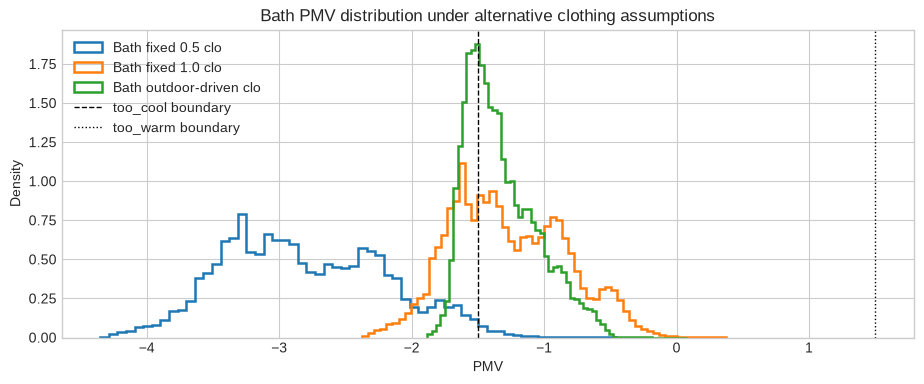

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
for values, label in [
    (bath_pmv_fixed_05, 'Bath fixed 0.5 clo'),
    (bath_pmv_fixed_10, 'Bath fixed 1.0 clo'),
    (bath_pmv_adaptive, 'Bath outdoor-driven clo'),
]:
    ax.hist(values, bins=60, density=True, histtype='step', linewidth=1.8, label=label)
ax.axvline(-1.5, color='black', linestyle='--', linewidth=1, label='too_cool boundary')
ax.axvline(1.5, color='black', linestyle=':', linewidth=1, label='too_warm boundary')
ax.set(title='Bath PMV distribution under alternative clothing assumptions', xlabel='PMV', ylabel='Density')
ax.legend()
plt.show()

#### Output explanation

**What the output is.** The figure overlays the three Bath PMV distributions and the cool/warm decision boundaries.

**What the output means.** Fixed 0.5 clo shifts nearly the entire Bath distribution into severe cold, creating the original one-class blocker. Outdoor-driven clothing moves the target into a non-degenerate cool-comfortable region but produces the narrowest PMV spread. None of the variants provides genuine support beyond the +1.5 warm boundary in the analysed period.

**Important interpretation boundary.** A visually broader or more balanced label distribution is not automatically more scientifically valid; assumptions must be justified independently of the desired result.

### Decomposing the fourfold Bath–LaSDPC signal gap

This is a multiplicative decomposition, not a claim that the two factors are causally independent. The temperature-spread ratio represents the observed building data. The effective PMV-response ratio includes the project's different clothing treatment. Logarithms express each factor's share of the total multiplicative gap.

### Code explanation: decompose the Bath-LaSDPC PMV signal gap

**Purpose.** Estimate how much of the fourfold PMV-spread difference is associated with building temperature spread and how much with effective PMV response, including clothing treatment.

**What the code does.**

1. Calculates the LaSDPC-to-Bath ratio of temperature standard deviation.
2. Calculates the ratio of PMV response per degree between the configured datasets.
3. Checks that multiplying those ratios reproduces the overall PMV standard-deviation ratio.
4. Uses logarithms to express each multiplicative factor as a share of the total log gap.

**Why this code is included.** This prevents the inaccurate one-cause statement that the Bath building is simply too uniform.

In [9]:
bath_temperature_std = environmental_variation.loc['Bath indoor', 'temperature std']
lasdpc_temperature_std = environmental_variation.loc['LaSDPC paired', 'temperature std']
bath_effective_response = pmv_variation.loc[
    'Bath, outdoor-driven clo', 'effective PMV spread / temperature spread'
]
lasdpc_effective_response = pmv_variation.loc[
    'LaSDPC, fixed 0.5 clo', 'effective PMV spread / temperature spread'
]

temperature_factor = lasdpc_temperature_std / bath_temperature_std
response_factor = lasdpc_effective_response / bath_effective_response
total_signal_factor = np.std(lasdpc_pmv) / np.std(bath_pmv_adaptive)
building_share = np.log(temperature_factor) / np.log(total_signal_factor)
assumption_share = np.log(response_factor) / np.log(total_signal_factor)

decomposition = pd.Series(
    {
        'temperature-spread factor (building)': temperature_factor,
        'effective-response factor (includes clothing choice)': response_factor,
        'combined PMV-signal factor': total_signal_factor,
        'log-share: building temperature spread': building_share,
        'log-share: effective response / clothing treatment': assumption_share,
    },
    name='signal-gap decomposition',
)
decomposition

temperature-spread factor (building)                    1.7121
effective-response factor (includes clothing choice)    2.3214
combined PMV-signal factor                              3.9730
log-share: building temperature spread                  0.3898
log-share: effective response / clothing treatment      0.6105
Name: signal-gap decomposition, dtype: float64

#### Output explanation

**What the output is.** The series reports a 1.7121-fold building temperature-spread factor, a 2.3214-fold effective-response factor and a combined 3.9730-fold PMV-signal difference. Their log shares are 38.98% and 61.05%, respectively.

**What the output means.** Roughly 39% of the multiplicative signal gap is associated with the narrower Bath temperature range and roughly 61% with the configured PMV response, which includes the clothing treatment. The larger measured contribution therefore comes from the modelling transformation rather than the building alone.

**Important interpretation boundary.** This is a descriptive multiplicative decomposition, not a causal identification study. The effective-response term can include interactions beyond clothing alone.

## 5. Signal relative to synthetic-label noise

The label generator adds Gaussian noise with configured standard deviation `σ=1.0`. Signal-to-noise is therefore `std(PMV) / σ`. The maximum-accuracy calculation is conditional on this exact synthetic-label process; it is not a bound on real-occupant comfort prediction.

LaSDPC uses three classes, so its ceiling is explicitly calculated with `merge_warm=False`. Bath uses the documented two-class merge.

### Code explanation: compare predictable signal with synthetic-label noise

**Purpose.** Estimate how much class-prediction headroom remains after applying the noisy synthetic oracle.

**What the code does.**

1. Calculates each target's number of classes, PMV spread and signal-to-noise ratio.
2. Finds the majority-class accuracy available without learning any feature relationship.
3. Uses the known Gaussian oracle to estimate the maximum conditional accuracy available from PMV.
4. Subtracts the majority baseline to obtain useful predictive headroom and reports PMV-vote agreement.

**Why this code is included.** Active learning cannot exploit noise that is independent of T+RH; the target must offer predictable headroom above a trivial majority prediction.

In [10]:
def signal_row(labelled, dataset, merge_warm):
    pmv_values = labelled[sl.PMV_VALUE].to_numpy()
    majority = labelled[sl.COMFORT_CLASS].value_counts(normalize=True).iloc[0]
    ceiling = validation.estimated_max_accuracy(
        pmv_values,
        noise_sigma=config.NOISE_STD,
        vote_threshold=config.COMFORT_VOTE_THRESHOLD,
        merge_warm=merge_warm,
    )
    return {
        'dataset': dataset,
        'classes': labelled[sl.COMFORT_CLASS].nunique(),
        'PMV std': np.std(pmv_values),
        'noise sigma': config.NOISE_STD,
        'signal / noise': np.std(pmv_values) / config.NOISE_STD,
        'majority baseline': majority,
        'conditional max accuracy': ceiling,
        'headroom': ceiling - majority,
        'PMV-vote agreement': sl.pmv_agreement_rate(labelled),
    }

signal_table = pd.DataFrame(
    [
        signal_row(bath_labelled, 'Bath', merge_warm=True),
        signal_row(lasdpc_labelled, 'LaSDPC', merge_warm=False),
    ]
).set_index('dataset')
signal_table

,classes,PMV std,noise sigma,signal / noise,majority baseline,conditional max accuracy,headroom,PMV-vote agreement
dataset,,,,,,,,
Bath,2,0.2689,1.0,0.2689,0.5649,0.5896,0.0246,0.3625
LaSDPC,3,1.0683,1.0,1.0683,0.6672,0.8086,0.1415,0.3653


#### Output explanation

**What the output is.** Bath has two observed target classes, signal-to-noise 0.2689, majority baseline 0.5649, estimated conditional ceiling 0.5896 and headroom 0.0246. LaSDPC has three classes, signal-to-noise 1.0683, baseline 0.6672, ceiling 0.8086 and headroom 0.1415. PMV-vote agreement is about 0.36 in both.

**What the output means.** The same noise calibration produces very different learnable headroom because the PMV signal differs. Bath offers only about 2.5 percentage points above its majority baseline, while LaSDPC offers about 14.2. Similar agreement rates confirm that the contrast is not caused by using an entirely different label generator.

**Important interpretation boundary.** An estimated ceiling is model-based diagnostic evidence, not a guarantee that a particular classifier or query strategy will attain it. The balanced empirical comparison remains decisive.

## 6. Why the monitored Bath period does not support `too_warm`

With the project's class mapping, the continuous noisy sensation crosses into `too_warm` above `+1.5` before rounding. A physically supported warm region would therefore require underlying PMV values near or above that boundary. Labels produced while every underlying PMV remains below it are tail-noise events, not a learnable warm environmental region.

### Code explanation: test support for the Bath warm class

**Purpose.** Determine whether `too_warm` labels would be supported by observed Bath conditions or produced only by the tail of the noise distribution.

**What the code does.**

1. Defines the continuous warm-class boundary at +1.5 on the noisy vote scale.
2. Uses the Gaussian cumulative distribution to calculate each row's theoretical probability of a warm vote.
3. Generates one seeded unmerged noisy-vote sample for a reproducible observed warm share.
4. Reports maximum temperature, maximum PMV, boundary coverage and theoretical/sample warm probabilities.

**Why this code is included.** A three-class classifier should not claim real-building warm performance when the monitored environment never enters the underlying warm region.

In [11]:
warm_boundary = config.COMFORT_VOTE_THRESHOLD + 0.5
p_too_warm = 1.0 - norm.cdf(
    warm_boundary, loc=bath_pmv_adaptive, scale=config.NOISE_STD
)
rng = np.random.default_rng(config.RANDOM_SEED)
sampled_vote = np.clip(
    np.rint(
        bath_pmv_adaptive
        + rng.normal(0.0, config.NOISE_STD, size=len(bath_pmv_adaptive))
    ),
    -3,
    3,
)

warm_support = pd.Series(
    {
        'maximum observed indoor temperature (degC)': bath_indoor[schema.TEMPERATURE].max(),
        'maximum underlying PMV': bath_pmv_adaptive.max(),
        'warm-class continuous boundary': warm_boundary,
        'readings with underlying PMV above warm boundary': int((bath_pmv_adaptive > warm_boundary).sum()),
        'maximum theoretical P(too_warm)': p_too_warm.max(),
        'mean theoretical P(too_warm)': p_too_warm.mean(),
        'sampled too_warm share before merging': (sampled_vote > config.COMFORT_VOTE_THRESHOLD).mean(),
    },
    name='Bath warm-class support',
)
warm_support

maximum observed indoor temperature (degC)          22.9270
maximum underlying PMV                               0.0766
warm-class continuous boundary                       1.5000
readings with underlying PMV above warm boundary     0.0000
maximum theoretical P(too_warm)                      0.0773
mean theoretical P(too_warm)                         0.0033
sampled too_warm share before merging                0.0034
Name: Bath warm-class support, dtype: float64

#### Output explanation

**What the output is.** The maximum Bath indoor temperature is 22.927 degrees C and maximum configured PMV is 0.0766, far below the +1.5 warm boundary. Zero readings cross that boundary. Mean theoretical warm probability is 0.0033 and the seeded unmerged draw produces a 0.0034 warm share.

**What the output means.** The monitored Bath period contains no physically supported warm PMV region. The tiny number of unmerged warm labels would be Gaussian tail events rather than examples of a learned warm environmental boundary. Merging that tail for the Bath evaluation avoids heavily weighting noise.

**Important interpretation boundary.** This does not justify converting the overall system permanently to two classes. The controlled experiment still evaluates all three classes, while Bath warm-condition performance remains unvalidated.

## 7. Reproducible checks and conclusion

### Code explanation: turn the main claims into executable checks

**Purpose.** Ensure the notebook fails if future data or configuration changes invalidate any conclusion stated in the narrative.

**What the code does.**

1. Constructs six Boolean statements covering weather agreement, relative dataset variation, humidity spread, clothing compression, signal-to-noise and warm-region support.
2. Displays the result of every statement.
3. Uses an assertion to stop execution unless all six are true.

**Why this code is included.** Executable claims make the justification auditable and prevent stale prose from surviving changed evidence.

In [12]:
checks = {
    'local station and building loggers track the same weather pattern': weather_correlation > 0.9,
    'Bath temperature varies less than LaSDPC': bath_temperature_std < lasdpc_temperature_std,
    'Bath humidity has non-trivial variation': environmental_variation.loc['Bath indoor', 'RH std'] > 1.0,
    'adaptive clothing compresses Bath PMV vs fixed 1.0 clo': np.std(bath_pmv_adaptive) < np.std(bath_pmv_fixed_10),
    'Bath PMV signal is smaller than configured label noise': np.std(bath_pmv_adaptive) < config.NOISE_STD,
    'Bath has no underlying too_warm PMV region in the monitored period': not (bath_pmv_adaptive > warm_boundary).any(),
}
check_table = pd.Series(checks, name='supported by computed evidence').to_frame()
display(check_table)
assert all(checks.values())
print('All justification checks passed.')

,supported by computed evidence
local station and building loggers track the same weather pattern,True
Bath temperature varies less than LaSDPC,True
Bath humidity has non-trivial variation,True
adaptive clothing compresses Bath PMV vs fixed 1.0 clo,True
Bath PMV signal is smaller than configured label noise,True
Bath has no underlying too_warm PMV region in the monitored period,True


All justification checks passed.


#### Output explanation

**What the output is.** A six-row table shows `True` for every evidence statement, followed by `All justification checks passed.`

**What the output means.** Every numerical condition required by this notebook's conclusion is supported by the currently loaded data and configuration. The final message also confirms that the notebook reached this point without a failed assertion.

**Important interpretation boundary.** These checks validate internal consistency under the current assumptions. They do not validate the synthetic oracle against real occupant votes.

### Evidence-supported conclusion

The observed Bath export is **not globally uniform**: temperature and humidity both vary, and high RH is materially present. However, compared with LaSDPC, Bath has a narrower temperature distribution, and the outdoor-temperature-driven clothing assumption further reduces the variation in PMV. Under the configured `σ=1.0` synthetic-label process, the remaining PMV spread is small relative to the noise.

The local weather context was explicitly considered. The clothing assumption uses the building's measured external loggers, which closely track the separate local weather station during their overlap. The correct bounded claim is therefore:

> **During the monitored November 2023–July 2024 period, under the measured indoor conditions and locally measured outdoor context, the export does not contain a physically supported `too_warm` PMV region. This does not imply that the building is never warm outside the monitored period.**

Finally, a balanced-looking sampled class distribution is not proof of learnability: independent Gaussian draws can create labels without creating a stable T+RH decision region. These results justify retaining Bath as a constrained two-class/null case study rather than forcing a three-class claim from unsupported conditions.